# 01 Polar H10 Multi-Stream EDA

This notebook provides local exploratory analysis for Polar H10 multi-stream sessions (`hr`, `acc`, `ecg`, and battery).

It complements `00_runbook.ipynb` for deeper validation and data-quality checks, and does not replace the runbook workflow.


## 1. Setup


In [24]:
from pathlib import Path
import json
import logging
import os
import sys

NOTEBOOK_ROOT = Path.cwd()
EXPECTED_PYTHON = (NOTEBOOK_ROOT / '.venv' / 'bin' / 'python').resolve()
CURRENT_PYTHON = Path(sys.executable).resolve()

# Avoid matplotlib cache permission issues in restricted environments.
os.environ.setdefault('MPLCONFIGDIR', str((NOTEBOOK_ROOT / '.mplconfig').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

if CURRENT_PYTHON != EXPECTED_PYTHON:
    raise RuntimeError(
        'Wrong Jupyter kernel selected.\n'
        f'Expected: {EXPECTED_PYTHON}\n'
        f'Current:  {CURRENT_PYTHON}\n'
        'Select kernel: Python (homelab notebooks) and restart Run All.'
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

LIB_PATH = NOTEBOOK_ROOT / 'lib'
if str(LIB_PATH) not in sys.path:
    sys.path.insert(0, str(LIB_PATH))

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s %(message)s')
load_dotenv(NOTEBOOK_ROOT / '.env')
sns.set_theme(style='whitegrid')

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 200)

from eda_helpers import (
    compute_gap_stats,
    detect_timestamp_column,
    downsample_df,
    ensure_datetime,
    merge_feature_streams_by_time,
    pick_first_column,
    stream_display_name,
)
from pipeline_client import run_full_pipeline
from remote_sync import get_session_by_id, list_sessions
from session_loader import load_clean, load_raw_chunks, load_summary, load_window_features


## 2. Runtime Parameters


In [25]:
# Runtime parameters
user_id = 2
session_id = '4fd8bc53-8971-4567-8c7f-81a3137c94da'
use_latest = True
run_pipeline = True
max_clean_rows_per_stream = 250000
max_feature_rows_per_stream = 80000
plot_downsample_points = 5000
battery_stream_alias = 'device_battery'
save_report = False

# ECG local view controls (for short-waveform preview only)
ecg_window_seconds = 10
ecg_window_start_offset_seconds = 0


## 3. Session Discovery and Selection


In [26]:
sessions = list_sessions(user_id=user_id, env_path=NOTEBOOK_ROOT / '.env')
print(f'Discovered {len(sessions)} sessions for user_id={user_id}')

if not sessions:
    raise RuntimeError('No sessions discovered. Check REMOTE_HOST/REMOTE_USER and wearable paths.')

session_table = pd.DataFrame(
    [
        {
            'session_id': s.get('session_id'),
            'streams': ','.join(s.get('available_streams', [])),
            'dates': ','.join(s.get('dates', [])),
            'cross_date': len(s.get('dates', [])) > 1,
            'cross_midnight_hint': 'possible' if len(s.get('dates', [])) > 1 else 'single-date',
        }
        for s in sessions
    ]
)
display(session_table)

if use_latest:
    selected_session_id = str(sessions[0]['session_id'])
else:
    selected_session_id = str(session_id).strip()

if not selected_session_id:
    raise ValueError('Set session_id or use_latest=True.')

print('Selected session_id:', selected_session_id)


2026-04-27 14:46:13,954 INFO remote_sync ssh_command_start
2026-04-27 14:46:14,331 INFO remote_sync ssh_command_success
2026-04-27 14:46:14,333 INFO remote_sync ssh_command_start
2026-04-27 14:46:14,633 INFO remote_sync ssh_command_success
2026-04-27 14:46:14,634 INFO remote_sync ssh_command_start
2026-04-27 14:46:14,851 INFO remote_sync ssh_command_success
2026-04-27 14:46:14,853 INFO remote_sync ssh_command_start
2026-04-27 14:46:15,186 INFO remote_sync ssh_command_success
2026-04-27 14:46:15,187 INFO remote_sync session_discovery_mode
2026-04-27 14:46:15,188 INFO remote_sync ssh_command_start
2026-04-27 14:46:15,584 INFO remote_sync ssh_command_success
2026-04-27 14:46:15,585 INFO remote_sync ssh_command_start
2026-04-27 14:46:15,905 INFO remote_sync ssh_command_success
2026-04-27 14:46:15,906 INFO remote_sync ssh_command_start
2026-04-27 14:46:16,159 INFO remote_sync ssh_command_success
2026-04-27 14:46:16,160 INFO remote_sync ssh_command_start
2026-04-27 14:46:16,484 INFO remote_s

Discovered 12 sessions for user_id=2


,session_id,streams,dates,cross_date,cross_midnight_hint
0,f2761664-0daf-472d-b4e9-11b9173a50e2,"hr,unknown",2026-04-26,False,single-date
1,c93f6d22-4edd-44f7-8749-cda389364255,hr,2026-04-26,False,single-date
2,c2bfb62e-3ac0-4e36-a6a1-e7a22f51652e,"hr,unknown",2026-04-26,False,single-date
3,b59aa7c3-8f24-4dbf-8c95-f08f62c9a945,"acc,ecg,hr,unknown",2026-04-26,False,single-date
4,8ee3db9d-d222-4927-bebf-69cdb90e7607,"hr,unknown",2026-04-26,False,single-date
5,886f9b46-b5f8-4be5-bf56-8795a22b1476,"hr,unknown",2026-04-26,False,single-date
6,707e5cd2-4bf1-4dff-9a5f-66a04a4ea9a8,"acc,ecg,hr,unknown",2026-04-26,False,single-date
7,6cb1d187-70d6-4ffb-9ca0-48c6cf315442,"hr,unknown",2026-04-26,False,single-date
8,6a7589b1-6043-444c-8ee5-99243f6a6c4f,"hr,unknown",2026-04-26,False,single-date
9,4fd8bc53-8971-4567-8c7f-81a3137c94da,"acc,ecg,hr,unknown","2026-04-26,2026-04-27",True,possible


Selected session_id: f2761664-0daf-472d-b4e9-11b9173a50e2


## 4. Optional Pipeline Run


In [27]:
selected_session_id = '4fd8bc53-8971-4567-8c7f-81a3137c94da'

pipeline_result = None
if run_pipeline:
    pipeline_result = run_full_pipeline(
        session_id=selected_session_id,
        user_id=user_id,
        env_path=NOTEBOOK_ROOT / '.env',
        poll_interval_seconds=3.0,
        live_progress=True,
    )

    summaries = pipeline_result.get('session_summaries', []) if isinstance(pipeline_result, dict) else []
    display(pd.DataFrame(summaries))

    if not summaries:
        print('WARNING: pipeline returned no selected-session summaries (partial or mismatched result).')

    if isinstance(pipeline_result, dict):
        status = str(pipeline_result.get('status', '')).lower()
        if status and status not in {'ok', 'success', 'completed'}:
            print(f'WARNING: pipeline status={status}')
else:
    print('Pipeline trigger skipped (run_pipeline=False).')


2026-04-27 14:48:05,654 INFO pipeline_client pipeline_run_start
2026-04-27 14:48:05,657 INFO remote_sync ssh_command_start
2026-04-27 14:48:05,838 INFO remote_sync ssh_command_success
2026-04-27 14:48:05,839 INFO remote_sync ssh_command_start
2026-04-27 14:48:06,066 INFO remote_sync ssh_command_success
2026-04-27 14:48:06,068 INFO remote_sync ssh_command_start
2026-04-27 14:48:07,291 WARNING remote_sync ssh_command_failed
2026-04-27 14:48:09,298 INFO remote_sync ssh_command_start
2026-04-27 14:48:10,516 WARNING remote_sync ssh_command_failed
2026-04-27 14:48:12,524 INFO remote_sync ssh_command_start
2026-04-27 14:48:13,771 WARNING remote_sync ssh_command_failed
2026-04-27 14:48:13,772 WARNING pipeline_client pipeline_progress_poll_failed
2026-04-27 14:48:16,776 INFO remote_sync ssh_command_start
2026-04-27 14:48:16,972 INFO remote_sync ssh_command_success
2026-04-27 14:48:16,975 INFO remote_sync ssh_command_start
2026-04-27 14:48:17,188 INFO remote_sync ssh_command_success
2026-04-27 1

Final step summary:
[normalize] status=success streams: success=8 skipped=0 failed=0
[window_features] status=success streams: success=8 skipped=0 failed=0
[build_session_summary] status=success streams: success=4 skipped=0 failed=0


,run_id,step_name,status,session_id,stream_success,stream_skipped,stream_failed,stream_statuses,warnings,state_path
0,91efbac6a4e34b14b5c0b520df13cc73,normalize,success,4fd8bc53-8971-4567-8c7f-81a3137c94da,8,0,0,"[acc:success, acc:success, ecg:success, ecg:success, hr:success, hr:success, unknown:success, unknown:success]",[line 21: missing required battery fields],/data/wearable/pipeline_runs/normalize/91efbac6a4e34b14b5c0b520df13cc73.json
1,79c20b58347747eebadb5ea6f72e68d7,window_features,success,4fd8bc53-8971-4567-8c7f-81a3137c94da,8,0,0,"[acc:success, acc:success, ecg:success, ecg:success, hr:success, hr:success, unknown:success, unknown:success]",[],/data/wearable/pipeline_runs/window_features/79c20b58347747eebadb5ea6f72e68d7.json
2,8702ab74b4994388a88e14df9f1ba9e0,build_session_summary,success,4fd8bc53-8971-4567-8c7f-81a3137c94da,4,0,0,"[hr:success, acc:success, ecg:success, device_battery:success]",[],/data/wearable/pipeline_runs/build_session_summary/8702ab74b4994388a88e14df9f1ba9e0.json


## 5. Sync Artifacts


In [28]:
session_cache_path = get_session_by_id(
    user_id=user_id,
    session_id=selected_session_id,
    local_cache_root=NOTEBOOK_ROOT / 'data_cache',
    env_path=NOTEBOOK_ROOT / '.env',
)
print('Local cache path:', session_cache_path)


2026-04-27 14:49:12,996 INFO remote_sync ssh_command_start
2026-04-27 14:49:13,255 INFO remote_sync ssh_command_success
2026-04-27 14:49:13,257 INFO remote_sync ssh_command_start
2026-04-27 14:49:13,522 INFO remote_sync ssh_command_success
2026-04-27 14:49:13,524 INFO remote_sync ssh_command_start
2026-04-27 14:49:13,879 INFO remote_sync ssh_command_success
2026-04-27 14:49:13,881 INFO remote_sync ssh_command_start
2026-04-27 14:49:14,286 INFO remote_sync ssh_command_success
2026-04-27 14:49:14,289 INFO remote_sync session_discovery_mode
2026-04-27 14:49:14,290 INFO remote_sync session_sync_start
2026-04-27 14:49:14,293 INFO remote_sync sync_start
2026-04-27 14:49:16,134 INFO remote_sync sync_success
2026-04-27 14:49:16,136 INFO remote_sync sync_start
2026-04-27 14:49:16,487 INFO remote_sync sync_success
2026-04-27 14:49:16,488 INFO remote_sync sync_start
2026-04-27 14:51:27,781 INFO remote_sync sync_success
2026-04-27 14:51:27,784 INFO remote_sync sync_start
2026-04-27 14:51:40,089 IN

Local cache path: /Users/maksymponomarenko/Documents/homelab/notebooks/data_cache/session_id=4fd8bc53-8971-4567-8c7f-81a3137c94da


## 6. Artifact Inventory


In [29]:
raw_chunks = load_raw_chunks(session_cache_path, preview_rows_per_stream=30, max_scan_lines_per_stream=30000)
clean_streams = load_clean(session_cache_path, max_rows_per_stream=max_clean_rows_per_stream)
window_features = load_window_features(session_cache_path, max_rows_per_stream=max_feature_rows_per_stream)
summary = load_summary(session_cache_path)

all_stream_keys = sorted(set(raw_chunks.keys()) | set(clean_streams.keys()) | set(window_features.keys()))
display_names = {}
for key in all_stream_keys:
    frame = clean_streams.get(key) if clean_streams.get(key) is not None else window_features.get(key)
    display_names[key] = stream_display_name(
        key,
        battery_stream_alias=battery_stream_alias,
        frame=frame,
        raw_item=raw_chunks.get(key),
    )

inventory_rows = []
for key in all_stream_keys:
    raw_item = raw_chunks.get(key)
    clean_df = clean_streams.get(key)
    feat_df = window_features.get(key)

    ts_col = detect_timestamp_column(clean_df) if clean_df is not None else None
    first_ts = None
    last_ts = None
    duration_seconds = None

    if clean_df is not None and not clean_df.empty and ts_col:
        temp = clean_df.copy()
        temp[ts_col] = pd.to_datetime(temp[ts_col], errors='coerce', utc=True)
        temp = temp.dropna(subset=[ts_col]).sort_values(ts_col)
        if not temp.empty:
            first_ts = temp[ts_col].iloc[0]
            last_ts = temp[ts_col].iloc[-1]
            duration_seconds = (last_ts - first_ts).total_seconds()

    if first_ts is None and isinstance(raw_item, dict):
        first_ts = raw_item.get('first_timestamp')
        last_ts = raw_item.get('last_timestamp')

    inventory_rows.append({
        'stream': display_names.get(key, key),
        'raw_present': bool(raw_item),
        'clean_present': clean_df is not None,
        'features_present': feat_df is not None,
        'raw_rows_observed': int(raw_item.get('observed_lines', 0)) if isinstance(raw_item, dict) else 0,
        'clean_rows': int(len(clean_df)) if clean_df is not None else 0,
        'feature_rows': int(len(feat_df)) if feat_df is not None else 0,
        'columns': list(clean_df.columns) if clean_df is not None else (list(feat_df.columns) if feat_df is not None else []),
        'first_ts': first_ts,
        'last_ts': last_ts,
        'duration_seconds': duration_seconds,
    })

inventory_df = pd.DataFrame(inventory_rows).sort_values('stream')
display(inventory_df)


2026-04-27 14:51:40,445 INFO session_loader raw_loaded
2026-04-27 14:51:40,593 INFO session_loader raw_loaded
2026-04-27 14:51:40,622 INFO session_loader raw_loaded
2026-04-27 14:51:40,623 INFO session_loader raw_loaded
2026-04-27 14:51:40,649 INFO session_loader raw_loaded
2026-04-27 14:51:40,673 INFO session_loader raw_loaded
2026-04-27 14:51:40,675 INFO session_loader raw_loaded
2026-04-27 14:51:40,676 INFO session_loader raw_loaded
2026-04-27 14:51:40,744 INFO session_loader clean_loaded
2026-04-27 14:51:40,793 INFO session_loader clean_loaded
2026-04-27 14:51:40,797 INFO session_loader clean_loaded
2026-04-27 14:51:40,798 INFO session_loader clean_loaded
2026-04-27 14:51:40,801 INFO session_loader window_features_loaded
2026-04-27 14:51:40,803 INFO session_loader window_features_loaded
2026-04-27 14:51:40,804 INFO session_loader window_features_loaded
2026-04-27 14:51:40,806 INFO session_loader window_features_loaded
2026-04-27 14:51:40,808 INFO session_loader summary_loaded


,stream,raw_present,clean_present,features_present,raw_rows_observed,clean_rows,feature_rows,columns,first_ts,last_ts,duration_seconds
0,acc,True,True,True,2150,250000,118,"[ts_utc, received_at_collector, uploaded_at_collector, received_at_server, session_id, stream_id, stream_type, payload_schema, user_id, source_vendor, source_device_model, source_device_id, collec...",2026-04-26 23:59:59.145000+00:00,2026-04-27 00:20:25.136000+00:00,1225.991
3,device_battery,True,True,True,24,23,48,"[ts_utc, received_at_collector, uploaded_at_collector, received_at_server, session_id, stream_id, stream_type, payload_schema, user_id, source_vendor, source_device_model, source_device_id, collec...",2026-04-27 00:00:43.452000+00:00,2026-04-27 00:36:54.596000+00:00,2171.144
1,ecg,True,True,True,1044,250000,118,"[ts_utc, received_at_collector, uploaded_at_collector, received_at_server, session_id, stream_id, stream_type, payload_schema, user_id, source_vendor, source_device_model, source_device_id, collec...",2026-04-26 23:59:57.840000+00:00,2026-04-27 00:32:01.337000+00:00,1923.497
2,hr,True,True,True,106,2124,118,"[ts_utc, received_at_collector, uploaded_at_collector, received_at_server, session_id, stream_id, stream_type, payload_schema, user_id, source_vendor, source_device_model, source_device_id, collec...",2026-04-26 23:59:51.898000+00:00,2026-04-27 00:35:15.081000+00:00,2123.183


## 7. Time Coverage and Gap Checks


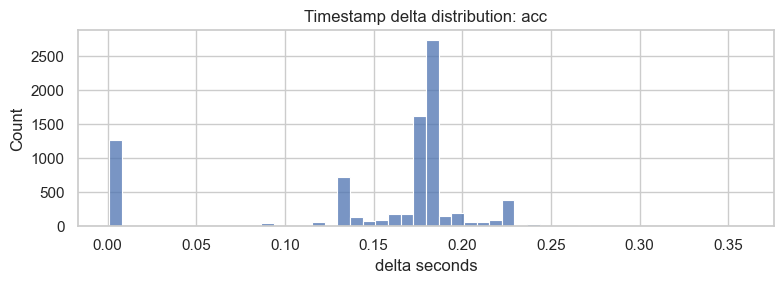

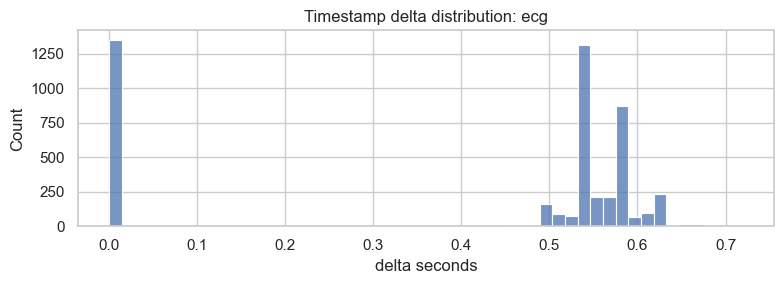

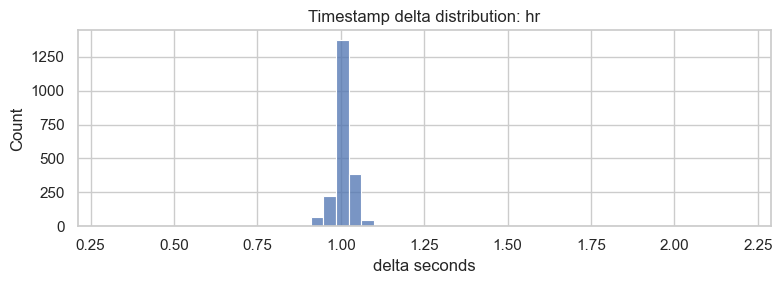

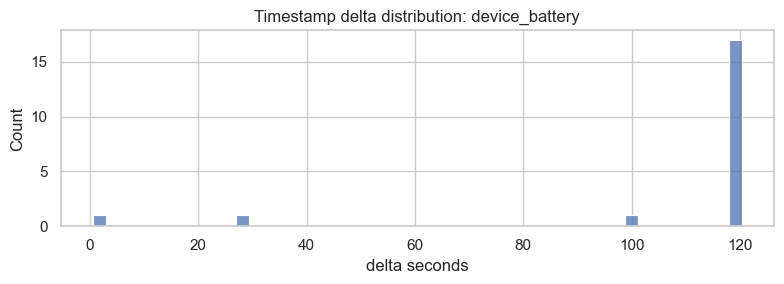

,stream,timestamp_col,first_ts,last_ts,duration_seconds,row_count,duplicate_timestamps,non_monotonic_count,median_delta_seconds,p95_delta_seconds,max_delta_seconds,sampling_interval_note
0,acc,ts_utc,2026-04-26 23:59:59.145000+00:00,2026-04-27 00:20:25.136000+00:00,1225.991,250000,241790,0,0.179,0.2240,0.358,observed ~5.6Hz vs expected ~200.0Hz
3,device_battery,ts_utc,2026-04-27 00:00:43.452000+00:00,2026-04-27 00:36:54.596000+00:00,2171.144,23,2,0,120.088,120.2024,120.286,
1,ecg,ts_utc,2026-04-26 23:59:57.840000+00:00,2026-04-27 00:32:01.337000+00:00,1923.497,250000,245223,0,0.540,0.6290,0.719,observed ~1.9Hz vs expected ~130.0Hz
2,hr,ts_utc,2026-04-26 23:59:51.898000+00:00,2026-04-27 00:35:15.081000+00:00,2123.183,2124,0,0,0.991,1.0400,2.194,


In [30]:
coverage_rows = []
for key, df in sorted(clean_streams.items()):
    if df is None or df.empty:
        continue

    display_name = display_names.get(key, key)
    local, ts_col = ensure_datetime(df)
    if ts_col is None or local.empty:
        coverage_rows.append({
            'stream': display_name,
            'timestamp_col': ts_col,
            'first_ts': None,
            'last_ts': None,
            'duration_seconds': None,
            'row_count': int(len(df)),
            'duplicate_timestamps': None,
            'non_monotonic_count': None,
            'median_delta_seconds': None,
            'p95_delta_seconds': None,
            'max_delta_seconds': None,
            'sampling_interval_note': 'timestamp column missing',
        })
        continue

    stats = compute_gap_stats(local[ts_col])
    first_ts = local[ts_col].iloc[0]
    last_ts = local[ts_col].iloc[-1]
    duration_seconds = (last_ts - first_ts).total_seconds()

    note = ''
    if display_name == 'acc':
        expected_hz_col = pick_first_column(local, ['sample_rate_hz'])
        expected_hz = float(local[expected_hz_col].dropna().median()) if expected_hz_col else 200.0
        if stats.median_delta_seconds:
            obs_hz = 1.0 / stats.median_delta_seconds
            note = f'observed ~{obs_hz:.1f}Hz vs expected ~{expected_hz:.1f}Hz'
    elif display_name == 'ecg':
        expected_hz_col = pick_first_column(local, ['sample_rate_hz'])
        expected_hz = float(local[expected_hz_col].dropna().median()) if expected_hz_col else 130.0
        if stats.median_delta_seconds:
            obs_hz = 1.0 / stats.median_delta_seconds
            note = f'observed ~{obs_hz:.1f}Hz vs expected ~{expected_hz:.1f}Hz'

    coverage_rows.append({
        'stream': display_name,
        'timestamp_col': ts_col,
        'first_ts': first_ts,
        'last_ts': last_ts,
        'duration_seconds': duration_seconds,
        'row_count': stats.row_count,
        'duplicate_timestamps': stats.duplicate_timestamps,
        'non_monotonic_count': stats.non_monotonic_count,
        'median_delta_seconds': stats.median_delta_seconds,
        'p95_delta_seconds': stats.p95_delta_seconds,
        'max_delta_seconds': stats.max_delta_seconds,
        'sampling_interval_note': note,
    })

    deltas = local[ts_col].diff().dt.total_seconds().dropna()
    deltas = deltas[deltas > 0]
    if len(deltas.index) > 10:
        plt.figure(figsize=(8, 3))
        sns.histplot(deltas, bins=50)
        plt.title(f'Timestamp delta distribution: {display_name}')
        plt.xlabel('delta seconds')
        plt.tight_layout()
        plt.show()

coverage_df = pd.DataFrame(coverage_rows).sort_values('stream')
display(coverage_df)


## 8. HR EDA


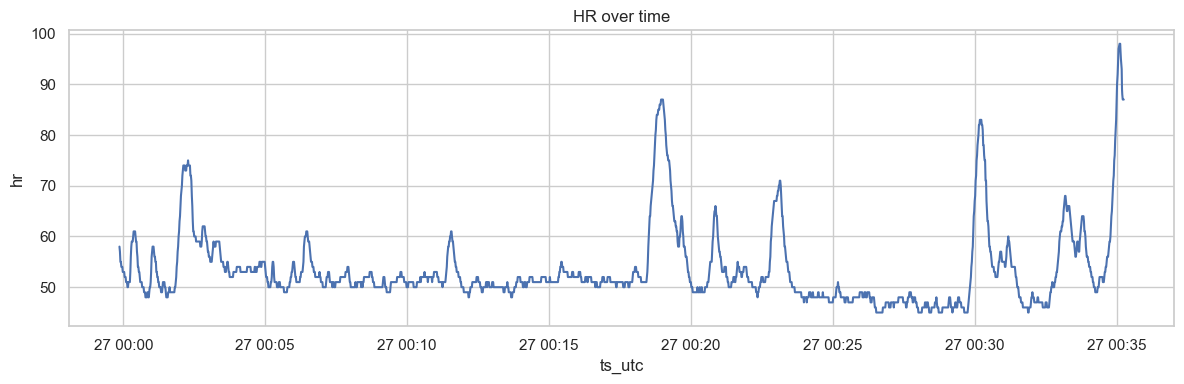

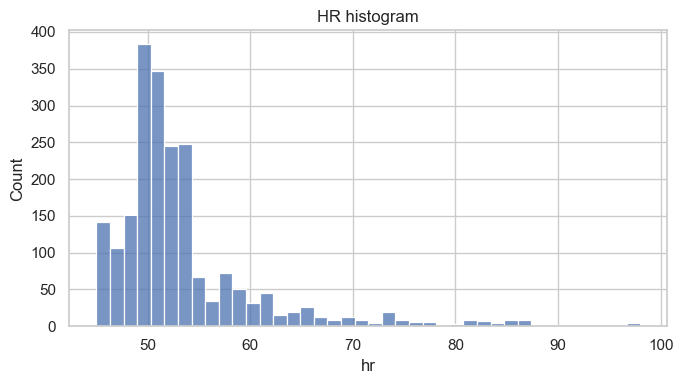

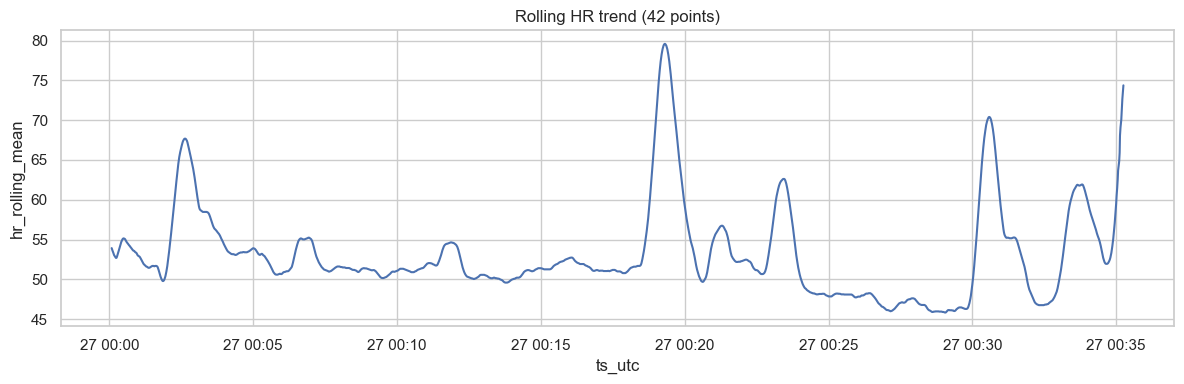

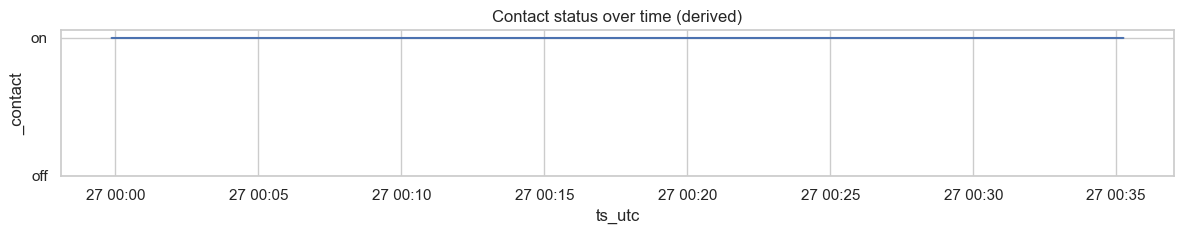

,missing_hr,implausible_hr_values,gap_p95_seconds,rr_availability_ratio
0,0,0,1.04,None


In [31]:
hr_key = next((k for k, v in display_names.items() if v == 'hr'), None)
hr_df = clean_streams.get(hr_key) if hr_key else None

if hr_df is None or hr_df.empty:
    print('No HR clean stream found.')
    hr_quality = {}
else:
    hr_df, hr_ts_col = ensure_datetime(hr_df)
    hr_col = pick_first_column(hr_df, ['hr', 'heart_rate'])
    rr_col = pick_first_column(hr_df, ['rr_ms', 'rr_interval_ms', 'rr'])
    contact_col = pick_first_column(hr_df, ['contact_status', 'contact', 'is_contact_detected', 'skin_contact'])

    if hr_ts_col is None or hr_col is None:
        print('HR stream exists but required columns are missing.')
        hr_quality = {}
    else:
        plot_hr = downsample_df(hr_df[[hr_ts_col, hr_col]].dropna(), max_points=plot_downsample_points, sort_col=hr_ts_col)

        plt.figure(figsize=(12, 4))
        sns.lineplot(data=plot_hr, x=hr_ts_col, y=hr_col)
        plt.title('HR over time')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 4))
        sns.histplot(hr_df[hr_col].dropna(), bins=40)
        plt.title('HR histogram')
        plt.tight_layout()
        plt.show()

        rolling_points = min(60, max(10, len(hr_df.index) // 50))
        trend = hr_df[[hr_ts_col, hr_col]].copy().dropna()
        trend['hr_rolling_mean'] = trend[hr_col].rolling(rolling_points, min_periods=max(3, rolling_points // 3)).mean()

        plt.figure(figsize=(12, 4))
        sns.lineplot(data=downsample_df(trend, max_points=plot_downsample_points, sort_col=hr_ts_col), x=hr_ts_col, y='hr_rolling_mean')
        plt.title(f'Rolling HR trend ({rolling_points} points)')
        plt.tight_layout()
        plt.show()

        rr_ratio = None
        if rr_col:
            rr_ratio = float(hr_df[rr_col].notna().mean())
            rr_plot = hr_df[[hr_ts_col, rr_col]].copy()
            rr_plot['rr_available'] = rr_plot[rr_col].notna().astype(int)
            plt.figure(figsize=(12, 2.5))
            sns.lineplot(data=downsample_df(rr_plot, max_points=plot_downsample_points, sort_col=hr_ts_col), x=hr_ts_col, y='rr_available')
            plt.title('RR availability over time')
            plt.yticks([0, 1], ['missing', 'present'])
            plt.tight_layout()
            plt.show()

        if contact_col:
            cplot = hr_df[[hr_ts_col, contact_col]].copy()
            cplot['_contact'] = cplot[contact_col].astype(str).str.lower().isin(['1', 'true', 'yes', 'contact', 'on']).astype(int)
            plt.figure(figsize=(12, 2.5))
            sns.lineplot(data=downsample_df(cplot, max_points=plot_downsample_points, sort_col=hr_ts_col), x=hr_ts_col, y='_contact')
            plt.title('Contact status over time (derived)')
            plt.yticks([0, 1], ['off', 'on'])
            plt.tight_layout()
            plt.show()

        hr_gaps = compute_gap_stats(hr_df[hr_ts_col])
        implausible = int(((hr_df[hr_col] < 30) | (hr_df[hr_col] > 230)).fillna(False).sum())
        missing_hr = int(hr_df[hr_col].isna().sum())
        hr_quality = {
            'missing_hr': missing_hr,
            'implausible_hr_values': implausible,
            'gap_p95_seconds': hr_gaps.p95_delta_seconds,
            'rr_availability_ratio': rr_ratio,
        }
        display(pd.DataFrame([hr_quality]))


## 9. ACC / Movement EDA


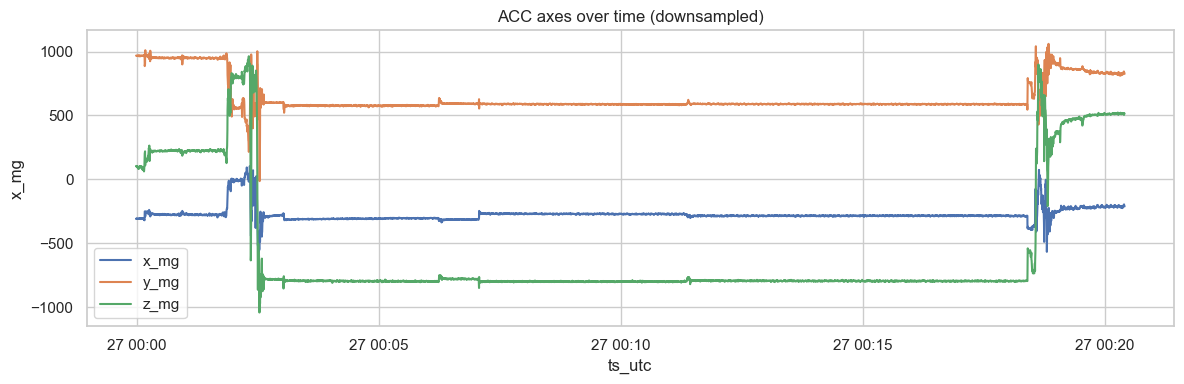

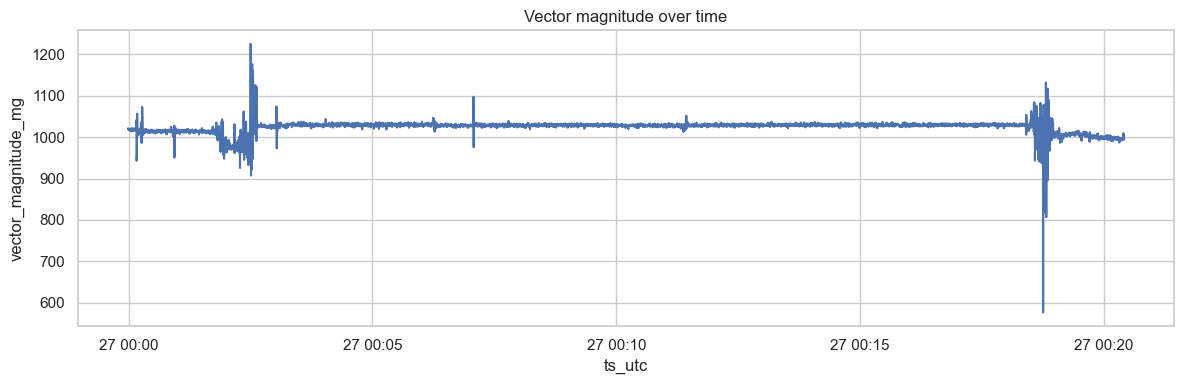

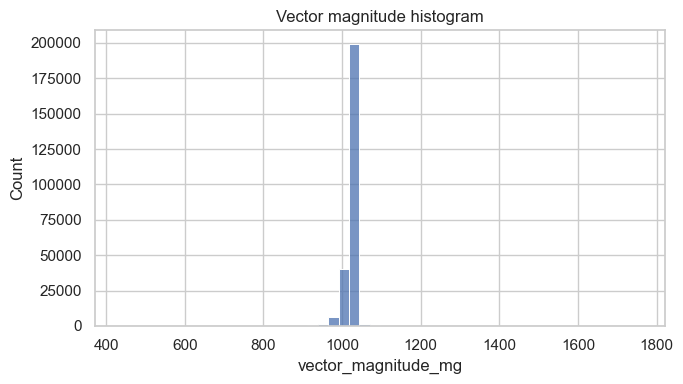

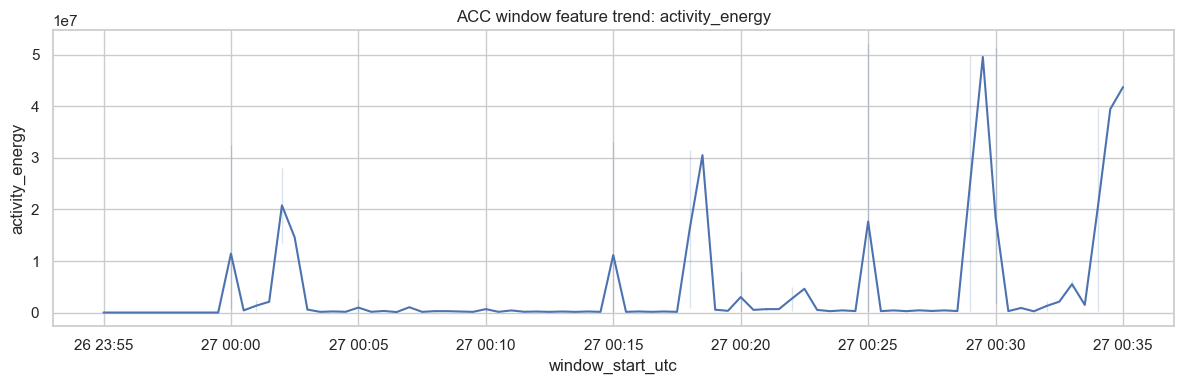

,missing_axis_values,duplicate_timestamps,gap_p95_seconds,extreme_values_count,stillness_ratio
0,0,241790,0.224,0,0.200004


In [32]:
acc_key = next((k for k, v in display_names.items() if v == 'acc'), None)
acc_df = clean_streams.get(acc_key) if acc_key else None
acc_feat = window_features.get(acc_key) if acc_key else None

if acc_df is None or acc_df.empty:
    print('No ACC clean stream found.')
    acc_quality = {}
else:
    acc_df, acc_ts_col = ensure_datetime(acc_df)
    x_col = pick_first_column(acc_df, ['x_mg', 'acc_x_mg', 'x'])
    y_col = pick_first_column(acc_df, ['y_mg', 'acc_y_mg', 'y'])
    z_col = pick_first_column(acc_df, ['z_mg', 'acc_z_mg', 'z'])

    if acc_ts_col is None or not all([x_col, y_col, z_col]):
        print('ACC stream exists but timestamp/axis columns are missing.')
        acc_quality = {}
    else:
        acc_work = acc_df.copy()
        vm_col = pick_first_column(acc_work, ['vector_magnitude_mg', 'vm_mg', 'acc_vector_magnitude_mg'])
        if vm_col is None:
            acc_work['vector_magnitude_mg'] = np.sqrt(acc_work[x_col] ** 2 + acc_work[y_col] ** 2 + acc_work[z_col] ** 2)
            vm_col = 'vector_magnitude_mg'

        p = downsample_df(acc_work[[acc_ts_col, x_col, y_col, z_col]], max_points=plot_downsample_points, sort_col=acc_ts_col)
        plt.figure(figsize=(12, 4))
        for col in [x_col, y_col, z_col]:
            sns.lineplot(data=p, x=acc_ts_col, y=col, label=col)
        plt.title('ACC axes over time (downsampled)')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12, 4))
        sns.lineplot(data=downsample_df(acc_work[[acc_ts_col, vm_col]], max_points=plot_downsample_points, sort_col=acc_ts_col), x=acc_ts_col, y=vm_col)
        plt.title('Vector magnitude over time')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 4))
        sns.histplot(acc_work[vm_col].dropna(), bins=50)
        plt.title('Vector magnitude histogram')
        plt.tight_layout()
        plt.show()

        still_threshold = float(acc_work[vm_col].dropna().quantile(0.2)) if acc_work[vm_col].notna().any() else 0.0
        acc_work['stillness_flag'] = (acc_work[vm_col] <= still_threshold).astype(int)
        stillness_ratio = float(acc_work['stillness_flag'].mean())

        if acc_feat is not None and not acc_feat.empty:
            feat_local, feat_ts = ensure_datetime(acc_feat)
            if feat_ts is not None:
                energy_col = pick_first_column(feat_local, ['activity_energy', 'vector_magnitude_mean', 'vector_magnitude_max'])
                if energy_col:
                    plt.figure(figsize=(12, 4))
                    sns.lineplot(
                        data=downsample_df(feat_local[[feat_ts, energy_col]], max_points=plot_downsample_points, sort_col=feat_ts),
                        x=feat_ts,
                        y=energy_col,
                    )
                    plt.title(f'ACC window feature trend: {energy_col}')
                    plt.tight_layout()
                    plt.show()

        gaps = compute_gap_stats(acc_work[acc_ts_col])
        extreme_values = int(((acc_work[[x_col, y_col, z_col]].abs() > 20000).any(axis=1)).sum())
        acc_quality = {
            'missing_axis_values': int(acc_work[[x_col, y_col, z_col]].isna().sum().sum()),
            'duplicate_timestamps': gaps.duplicate_timestamps,
            'gap_p95_seconds': gaps.p95_delta_seconds,
            'extreme_values_count': extreme_values,
            'stillness_ratio': stillness_ratio,
        }
        display(pd.DataFrame([acc_quality]))


## 10. ECG EDA


Note: This notebook does not perform clinical interpretation, diagnosis, QRS detection, or R-peak detection.


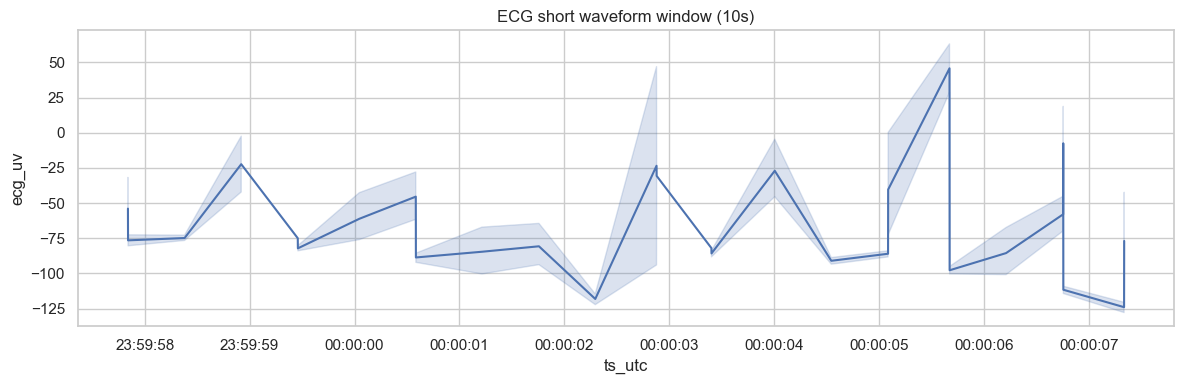

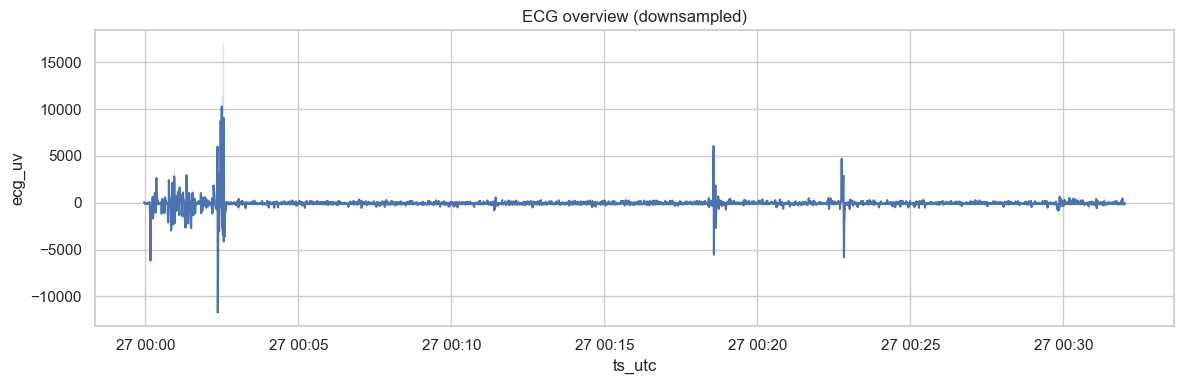

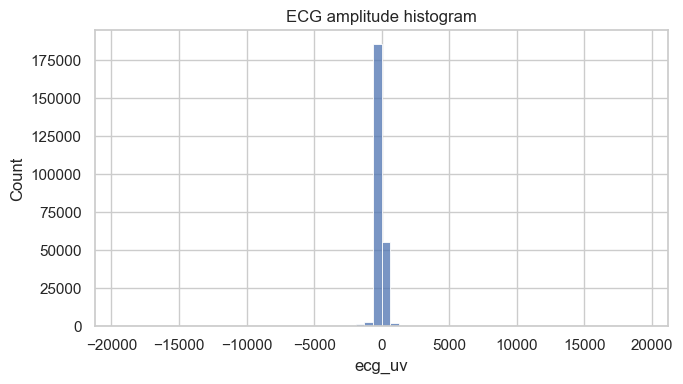

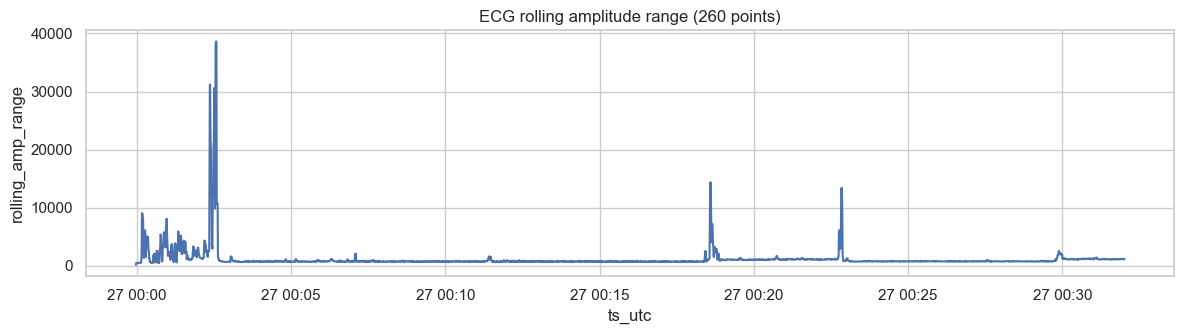

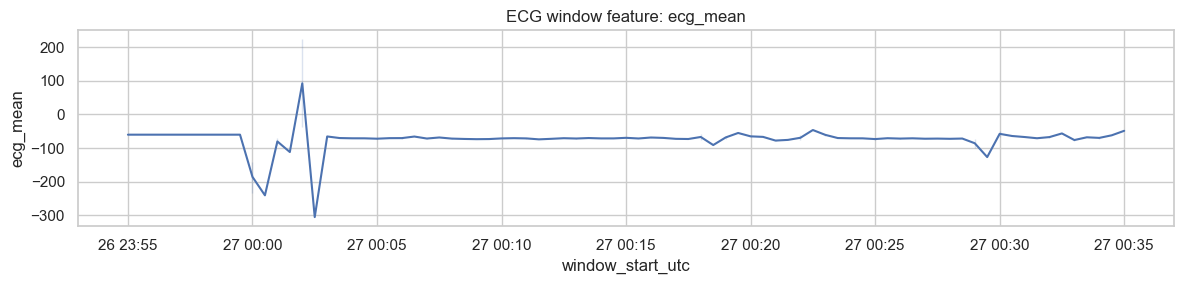

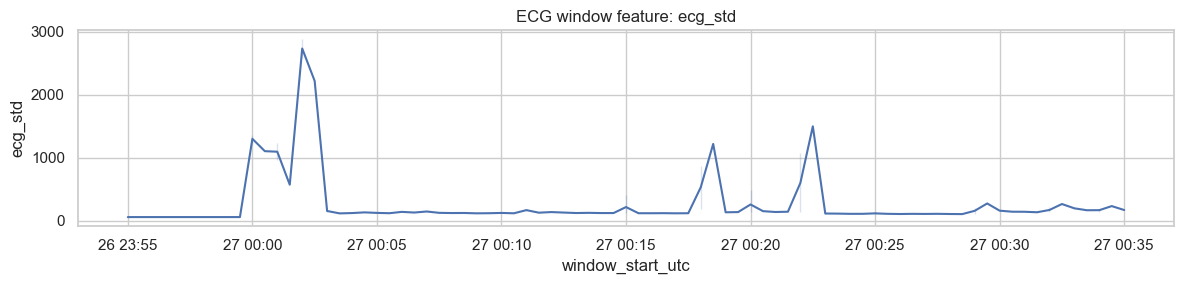

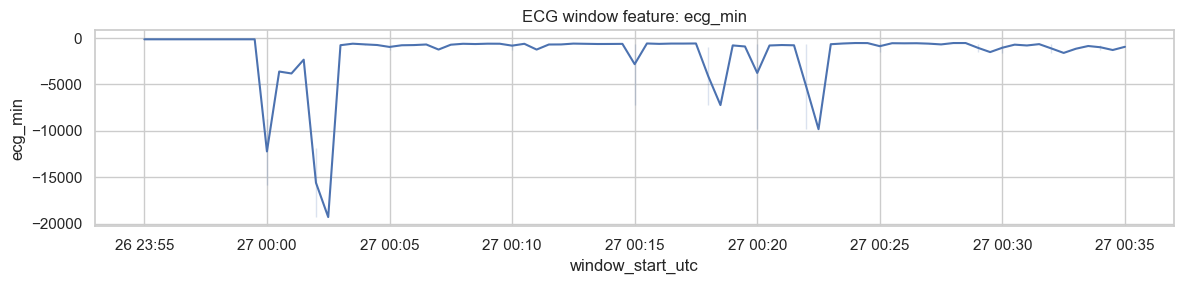

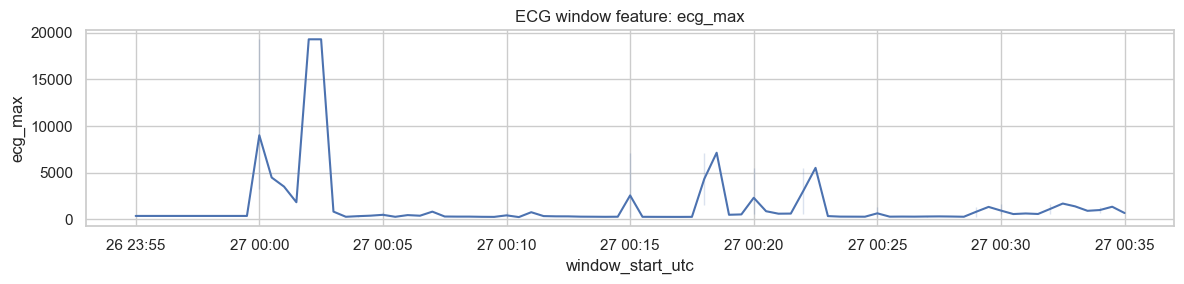

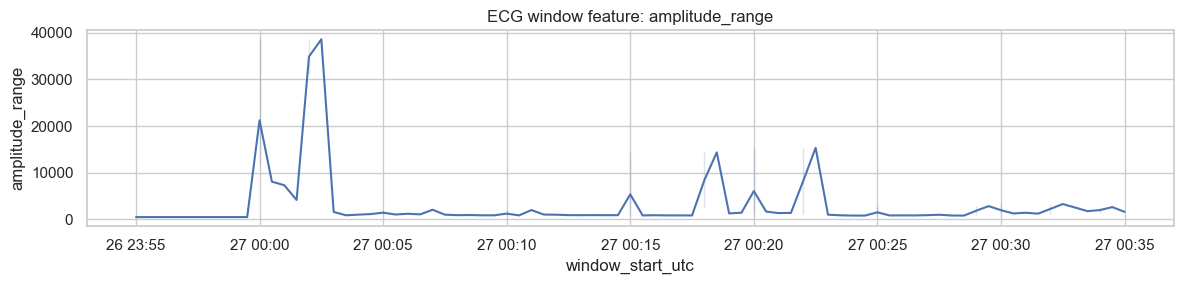

,missing_values,flatline_like_windows,extreme_spike_count,gap_p95_seconds
0,0,19,469,0.629


In [33]:
print('Note: This notebook does not perform clinical interpretation, diagnosis, QRS detection, or R-peak detection.')

ecg_key = next((k for k, v in display_names.items() if v == 'ecg'), None)
ecg_df = clean_streams.get(ecg_key) if ecg_key else None
ecg_feat = window_features.get(ecg_key) if ecg_key else None

if ecg_df is None or ecg_df.empty:
    print('No ECG clean stream found.')
    ecg_quality = {}
else:
    ecg_df, ecg_ts_col = ensure_datetime(ecg_df)
    ecg_col = pick_first_column(ecg_df, ['ecg_uv', 'ecg', 'ecg_microvolts'])

    if ecg_ts_col is None or ecg_col is None:
        print('ECG stream exists but timestamp/amplitude columns are missing.')
        ecg_quality = {}
    else:
        ecg_plot = downsample_df(ecg_df[[ecg_ts_col, ecg_col]].dropna(), max_points=plot_downsample_points, sort_col=ecg_ts_col)

        # Short selectable waveform window
        start_ts = ecg_df[ecg_ts_col].min() + pd.to_timedelta(ecg_window_start_offset_seconds, unit='s')
        end_ts = start_ts + pd.to_timedelta(ecg_window_seconds, unit='s')
        ecg_short = ecg_df[(ecg_df[ecg_ts_col] >= start_ts) & (ecg_df[ecg_ts_col] <= end_ts)]

        if not ecg_short.empty:
            plt.figure(figsize=(12, 4))
            sns.lineplot(data=ecg_short, x=ecg_ts_col, y=ecg_col)
            plt.title(f'ECG short waveform window ({ecg_window_seconds}s)')
            plt.tight_layout()
            plt.show()

        plt.figure(figsize=(12, 4))
        sns.lineplot(data=ecg_plot, x=ecg_ts_col, y=ecg_col)
        plt.title('ECG overview (downsampled)')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 4))
        sns.histplot(ecg_df[ecg_col].dropna(), bins=60)
        plt.title('ECG amplitude histogram')
        plt.tight_layout()
        plt.show()

        roll_points = min(260, max(40, len(ecg_df.index) // 80))
        ecg_roll = ecg_df[[ecg_ts_col, ecg_col]].copy().dropna()
        ecg_roll['rolling_amp_range'] = ecg_roll[ecg_col].rolling(roll_points, min_periods=max(5, roll_points // 5)).apply(lambda x: float(np.max(x) - np.min(x)), raw=True)

        plt.figure(figsize=(12, 3.5))
        sns.lineplot(
            data=downsample_df(ecg_roll[[ecg_ts_col, 'rolling_amp_range']].dropna(), max_points=plot_downsample_points, sort_col=ecg_ts_col),
            x=ecg_ts_col,
            y='rolling_amp_range',
        )
        plt.title(f'ECG rolling amplitude range ({roll_points} points)')
        plt.tight_layout()
        plt.show()

        if ecg_feat is not None and not ecg_feat.empty:
            feat_local, feat_ts = ensure_datetime(ecg_feat)
            if feat_ts is not None:
                for col in ['mean', 'std', 'min', 'max', 'amplitude_range']:
                    match = pick_first_column(feat_local, [col, f'ecg_{col}', f'value_{col}'])
                    if not match:
                        continue
                    plt.figure(figsize=(12, 3))
                    sns.lineplot(
                        data=downsample_df(feat_local[[feat_ts, match]].dropna(), max_points=plot_downsample_points, sort_col=feat_ts),
                        x=feat_ts,
                        y=match,
                    )
                    plt.title(f'ECG window feature: {match}')
                    plt.tight_layout()
                    plt.show()

        gaps = compute_gap_stats(ecg_df[ecg_ts_col])
        flatline_like = int(
            ecg_df[ecg_col]
            .rolling(80, min_periods=20)
            .std()
            .fillna(0)
            .lt(1e-6)
            .sum()
        )
        extreme_spikes = int((ecg_df[ecg_col].abs() > ecg_df[ecg_col].dropna().quantile(0.999)).fillna(False).sum())

        ecg_quality = {
            'missing_values': int(ecg_df[ecg_col].isna().sum()),
            'flatline_like_windows': flatline_like,
            'extreme_spike_count': extreme_spikes,
            'gap_p95_seconds': gaps.p95_delta_seconds,
        }
        display(pd.DataFrame([ecg_quality]))


## 11. Battery EDA


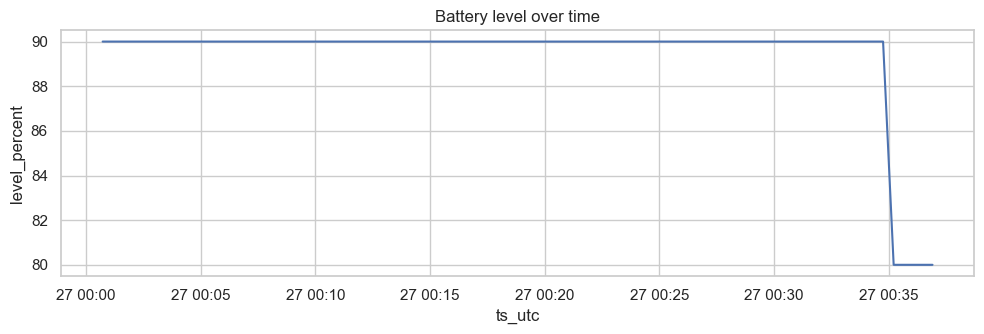

,first_level,last_level,min_level,max_level,mean_level,drain_per_hour,observed_charge_states
0,90.0,80.0,80.0,90.0,87.826087,16.58112,unknown


,ts_utc,level_percent,charge_state,level_delta
0,2026-04-27 00:00:43.452000+00:00,90.0,unknown,NaN
1,2026-04-27 00:02:43.462000+00:00,90.0,unknown,0.0
2,2026-04-27 00:04:43.607000+00:00,90.0,unknown,0.0
3,2026-04-27 00:06:43.645000+00:00,90.0,unknown,0.0
4,2026-04-27 00:08:43.931000+00:00,90.0,unknown,0.0
5,2026-04-27 00:10:43.988000+00:00,90.0,unknown,0.0
6,2026-04-27 00:12:44.035000+00:00,90.0,unknown,0.0
7,2026-04-27 00:14:44.133000+00:00,90.0,unknown,0.0
8,2026-04-27 00:16:44.269000+00:00,90.0,unknown,0.0
9,2026-04-27 00:18:44.453000+00:00,90.0,unknown,0.0


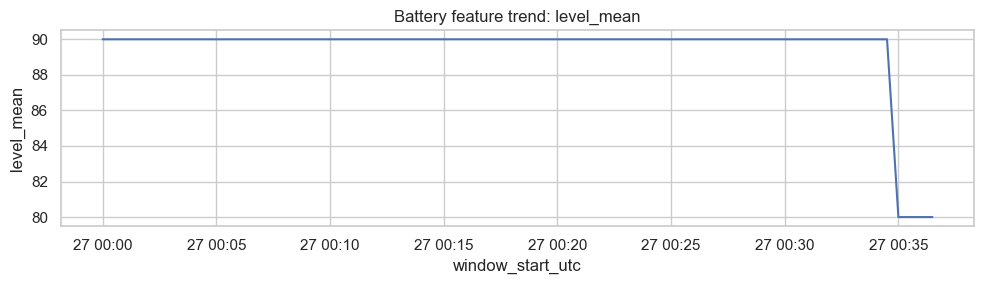

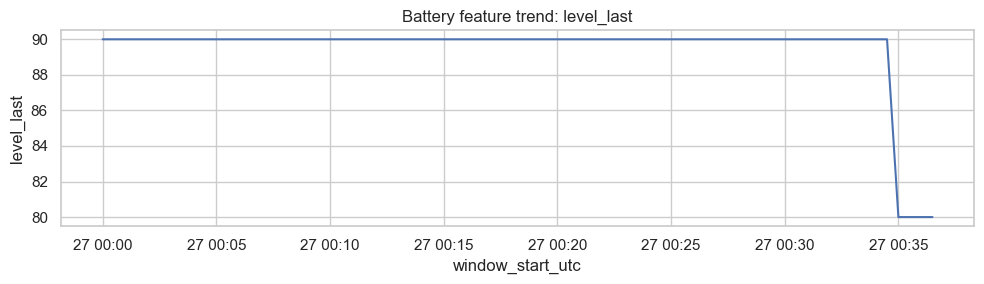

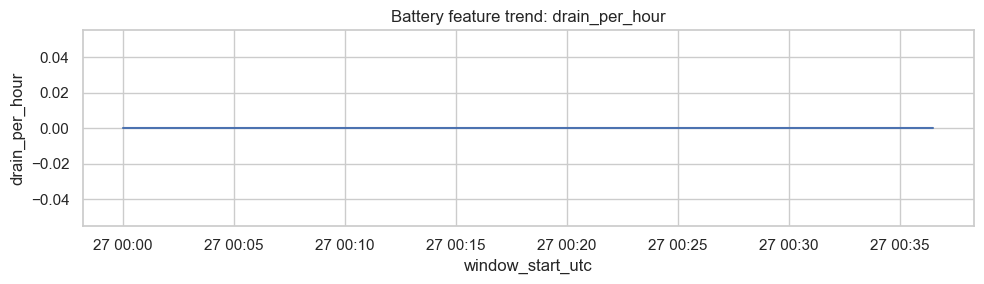

In [34]:
battery_key = next((k for k, v in display_names.items() if v == battery_stream_alias), None)
battery_df = clean_streams.get(battery_key) if battery_key else None
battery_feat = window_features.get(battery_key) if battery_key else None

if battery_df is None or battery_df.empty:
    print('No clean battery stream found. Trying window features only...')
    battery_quality = {}
else:
    battery_df, b_ts_col = ensure_datetime(battery_df)
    level_col = pick_first_column(battery_df, ['battery_level', 'level_percent', 'level', 'battery_percent'])
    state_col = pick_first_column(battery_df, ['charge_state', 'state', 'battery_state'])

    if b_ts_col is None or level_col is None:
        print('Battery stream exists but timestamp/level columns are missing.')
        battery_quality = {}
    else:
        bplot = downsample_df(battery_df[[b_ts_col, level_col]].dropna(), max_points=plot_downsample_points, sort_col=b_ts_col)
        plt.figure(figsize=(10, 3.5))
        sns.lineplot(data=bplot, x=b_ts_col, y=level_col)
        plt.title('Battery level over time')
        plt.tight_layout()
        plt.show()

        first_level = float(battery_df[level_col].dropna().iloc[0]) if battery_df[level_col].notna().any() else None
        last_level = float(battery_df[level_col].dropna().iloc[-1]) if battery_df[level_col].notna().any() else None
        min_level = float(battery_df[level_col].min()) if battery_df[level_col].notna().any() else None
        max_level = float(battery_df[level_col].max()) if battery_df[level_col].notna().any() else None
        mean_level = float(battery_df[level_col].mean()) if battery_df[level_col].notna().any() else None

        drain_per_hour = None
        if len(battery_df.index) >= 3:
            elapsed_h = (battery_df[b_ts_col].iloc[-1] - battery_df[b_ts_col].iloc[0]).total_seconds() / 3600.0
            if elapsed_h > 0:
                drain_per_hour = (first_level - last_level) / elapsed_h if first_level is not None and last_level is not None else None

        observed_states = []
        if state_col:
            observed_states = sorted({str(v) for v in battery_df[state_col].dropna().unique()})

        battery_quality = {
            'first_level': first_level,
            'last_level': last_level,
            'min_level': min_level,
            'max_level': max_level,
            'mean_level': mean_level,
            'drain_per_hour': drain_per_hour,
            'observed_charge_states': ', '.join(observed_states),
        }
        display(pd.DataFrame([battery_quality]))

        events_cols = [c for c in [b_ts_col, level_col, state_col] if c]
        events = battery_df[events_cols].copy()
        if level_col in events.columns:
            events['level_delta'] = events[level_col].diff()
        display(events.head(50))

        if len(battery_df.index) < 10:
            print('Note: Short or sparse battery sessions are insufficient for long-term degradation conclusions.')

if battery_feat is not None and not battery_feat.empty:
    bfeat_local, bfeat_ts = ensure_datetime(battery_feat)
    if bfeat_ts is not None:
        key_cols = [
            pick_first_column(bfeat_local, ['level_mean']),
            pick_first_column(bfeat_local, ['level_last']),
            pick_first_column(bfeat_local, ['drain_per_hour']),
        ]
        key_cols = [c for c in key_cols if c]
        if key_cols:
            for col in key_cols:
                plt.figure(figsize=(10, 3))
                sns.lineplot(data=downsample_df(bfeat_local[[bfeat_ts, col]].dropna(), max_points=plot_downsample_points, sort_col=bfeat_ts), x=bfeat_ts, y=col)
                plt.title(f'Battery feature trend: {col}')
                plt.tight_layout()
                plt.show()


## 12. Window Features Analysis



Stream: acc
Window sizes: {'30s': 72, '1m': 37, '5m': 9}


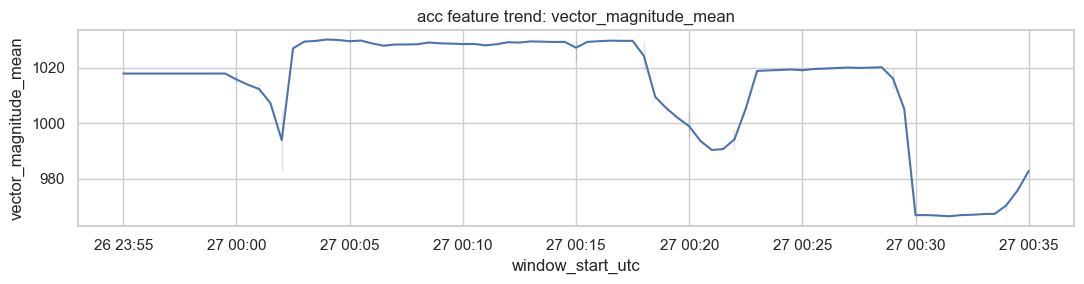

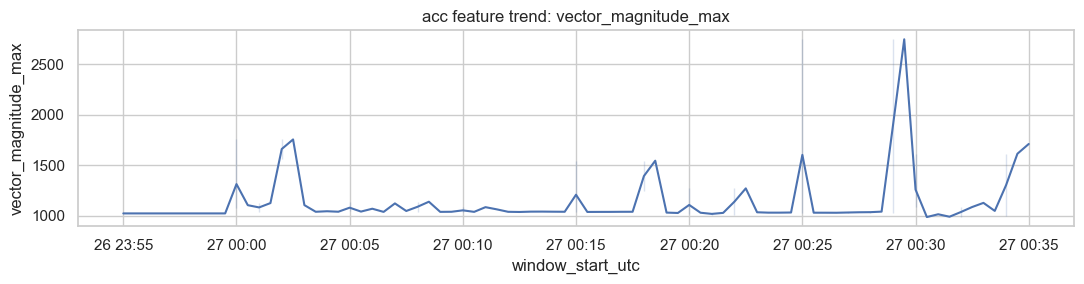

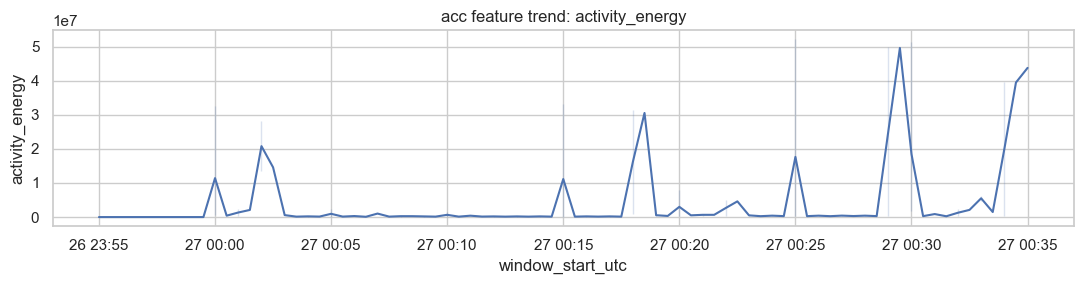


Stream: ecg
Window sizes: {'30s': 72, '1m': 37, '5m': 9}


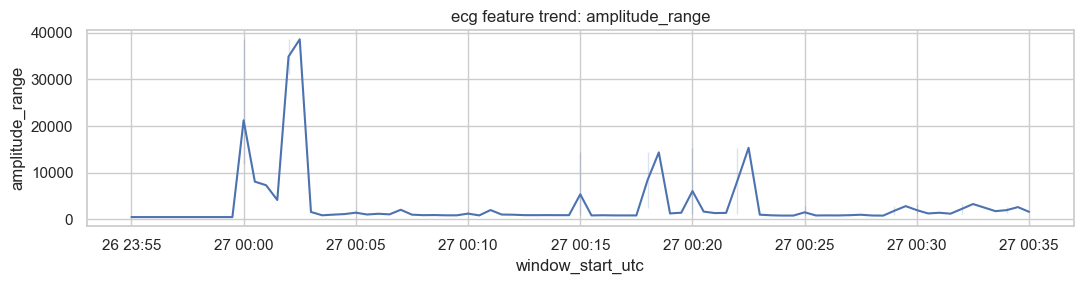

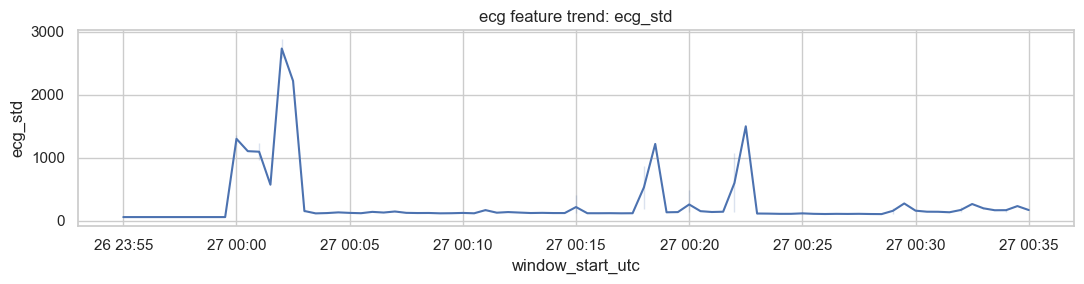


Stream: hr
Window sizes: {'30s': 72, '1m': 37, '5m': 9}


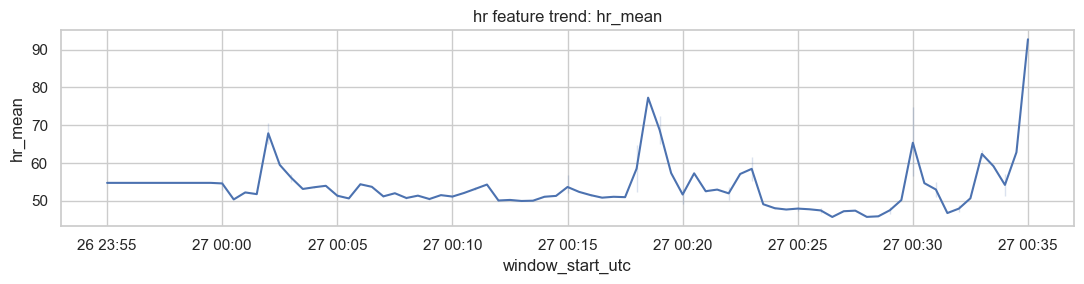

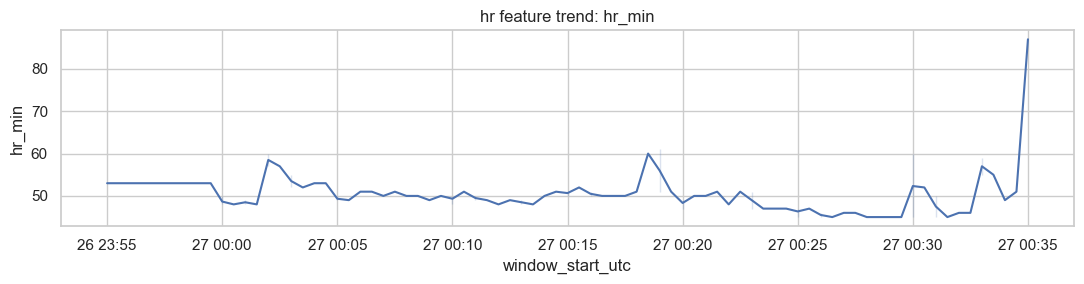

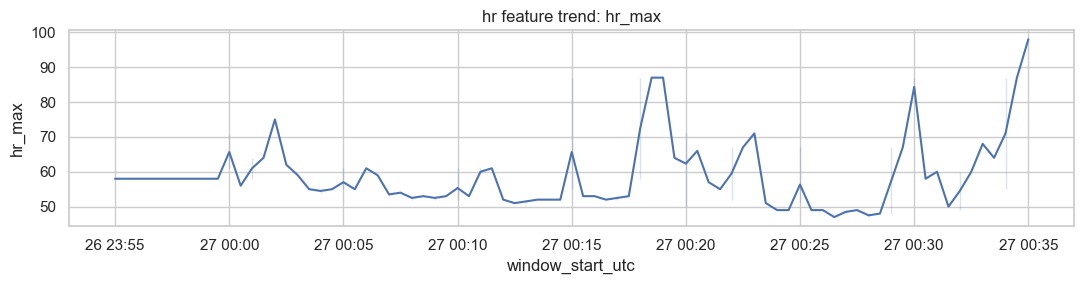


Stream: device_battery
Window sizes: {'1m': 20, '30s': 20, '5m': 8}


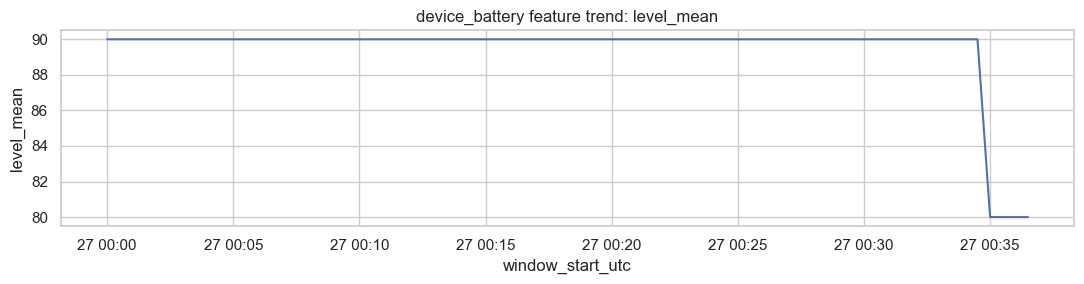

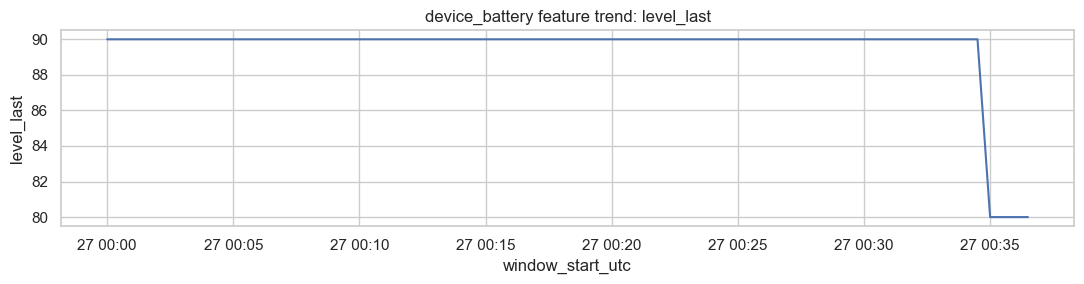

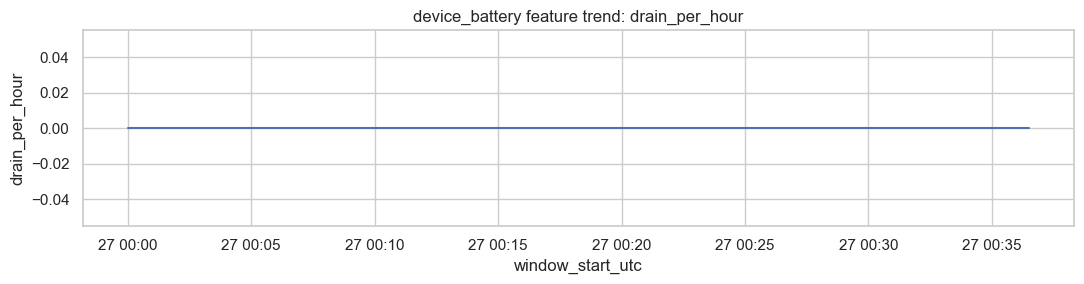

In [35]:
for key, feat_df in sorted(window_features.items()):
    if feat_df is None or feat_df.empty:
        continue

    stream_name = display_names.get(key, key)
    local, ts_col = ensure_datetime(feat_df)
    ws_col = pick_first_column(local, ['window_size_seconds', 'window_size_sec', 'window_size', 'window_sec'])

    print(f'\nStream: {stream_name}')
    if ws_col:
        print('Window sizes:', local[ws_col].value_counts(dropna=False).to_dict())
    else:
        print('Window sizes: column not found')

    if ts_col is None:
        continue

    stream_candidates = {
        'hr': ['mean_hr', 'hr_mean', 'hr_min', 'hr_max', 'mean', 'min', 'max'],
        'acc': ['vector_magnitude_mean', 'vector_magnitude_max', 'activity_energy'],
        'ecg': ['amplitude_range', 'std', 'ecg_std', 'ecg_amplitude_range'],
        battery_stream_alias: ['level_mean', 'level_last', 'drain_per_hour'],
    }

    candidates = stream_candidates.get(stream_name, [])
    plotted = 0
    for candidate in candidates:
        col = pick_first_column(local, [candidate])
        if not col:
            continue
        plotted += 1
        plt.figure(figsize=(11, 3))
        sns.lineplot(data=downsample_df(local[[ts_col, col]].dropna(), max_points=plot_downsample_points, sort_col=ts_col), x=ts_col, y=col)
        plt.title(f'{stream_name} feature trend: {col}')
        plt.tight_layout()
        plt.show()

    if plotted == 0:
        print('No configured key feature columns found for this stream.')


## 13. Cross-Stream Exploratory Analysis


Exploratory only: hypothesis-generating, not causal and not production logic.
Joined rows: 118


,window_ts,acc__sample_count,acc__mean_x,acc__mean_y,acc__mean_z,acc__std_x,acc__std_y,acc__std_z,acc__min_x,acc__min_y,acc__min_z,acc__max_x,acc__max_y,device_battery__sample_count,device_battery__level_min,device_battery__level_max,device_battery__level_mean,device_battery__level_first,device_battery__level_last,device_battery__samples_count,device_battery__drain_per_hour,ecg__sample_count,ecg__ecg_mean,ecg__ecg_std,ecg__ecg_min,ecg__ecg_max,ecg__amplitude_range,ecg__abs_mean,hr__sample_count,hr__hr_mean,hr__hr_min,hr__hr_max,hr__hr_std,hr__hr_median,hr__hr_first,hr__hr_last,hr__coverage_ratio
0,2026-04-26 23:55:00+00:00,155,-307.509677,965.187097,100.083871,1.411326,1.676352,2.516923,-311.0,959.0,93.0,-304.0,969.0,1,90.0,90.0,90.0,90.0,90.0,1,NaN,255,-60.364706,55.473190,-136.0,372.0,508.0,75.713725,9,54.777778,53.0,58.0,1.617802,54.0,58.0,53.0,0.026553
1,2026-04-26 23:59:00+00:00,155,-307.509677,965.187097,100.083871,1.411326,1.676352,2.516923,-311.0,959.0,93.0,-304.0,969.0,1,90.0,90.0,90.0,90.0,90.0,1,NaN,255,-60.364706,55.473190,-136.0,372.0,508.0,75.713725,9,54.777778,53.0,58.0,1.617802,54.0,58.0,53.0,0.132767
2,2026-04-26 23:59:30+00:00,155,-307.509677,965.187097,100.083871,1.411326,1.676352,2.516923,-311.0,959.0,93.0,-304.0,969.0,1,90.0,90.0,90.0,90.0,90.0,1,NaN,255,-60.364706,55.473190,-136.0,372.0,508.0,75.713725,9,54.777778,53.0,58.0,1.617802,54.0,58.0,53.0,0.265533
3,2026-04-27 00:00:00+00:00,6120,-281.412255,958.232190,169.644444,20.993054,11.524789,59.030551,-347.0,869.0,33.0,-224.0,1019.0,3,90.0,90.0,90.0,90.0,90.0,3,0.0,39055,-100.056228,1354.754736,-19300.0,19297.0,38597.0,534.179798,300,55.783333,48.0,75.0,6.224927,54.0,53.0,54.0,0.996610
4,2026-04-27 00:00:00+00:00,12240,-278.338971,954.172958,196.052533,15.734461,10.237462,49.599138,-347.0,869.0,33.0,-224.0,1036.0,3,90.0,90.0,90.0,90.0,90.0,3,0.0,39055,-100.056228,1354.754736,-19300.0,19297.0,38597.0,534.179798,300,55.783333,48.0,75.0,6.224927,54.0,53.0,54.0,0.996610
5,2026-04-27 00:00:00+00:00,61200,-262.464592,719.852451,-224.865686,99.548114,189.568101,594.368908,-782.0,-113.0,-1105.0,538.0,1467.0,3,90.0,90.0,90.0,90.0,90.0,3,0.0,39055,-100.056228,1354.754736,-19300.0,19297.0,38597.0,534.179798,300,55.783333,48.0,75.0,6.224927,54.0,53.0,54.0,0.996610
6,2026-04-27 00:00:30+00:00,6120,-275.265686,950.113725,222.460621,5.962218,6.620858,6.385038,-317.0,877.0,174.0,-242.0,1036.0,1,90.0,90.0,90.0,90.0,90.0,1,NaN,3869,-240.543034,1103.575017,-3611.0,4490.0,8101.0,743.522616,30,50.400000,48.0,56.0,2.075251,50.0,54.0,56.0,0.967533
7,2026-04-27 00:01:00+00:00,12240,-245.293709,917.364134,281.342320,81.683162,94.215160,158.687771,-315.0,478.0,101.0,22.0,1059.0,1,90.0,90.0,90.0,90.0,90.0,1,NaN,3942,-70.073567,1228.923513,-3819.0,3515.0,7334.0,902.680873,30,52.400000,49.0,58.0,3.028751,51.0,57.0,49.0,0.966000
8,2026-04-27 00:01:00+00:00,6120,-276.890359,949.686765,222.750654,4.240742,3.039891,4.874462,-314.0,921.0,156.0,-249.0,973.0,1,90.0,90.0,90.0,90.0,90.0,1,NaN,3942,-70.073567,1228.923513,-3819.0,3515.0,7334.0,902.680873,30,52.400000,49.0,58.0,3.028751,51.0,57.0,49.0,0.966000
9,2026-04-27 00:01:30+00:00,6120,-213.697059,885.041503,339.933987,106.440582,125.116933,208.503934,-315.0,478.0,101.0,22.0,1059.0,1,90.0,90.0,90.0,90.0,90.0,1,NaN,3869,-111.941845,570.302013,-2332.0,1840.0,4172.0,407.223314,30,51.800000,48.0,64.0,4.749737,49.0,48.0,64.0,0.966033


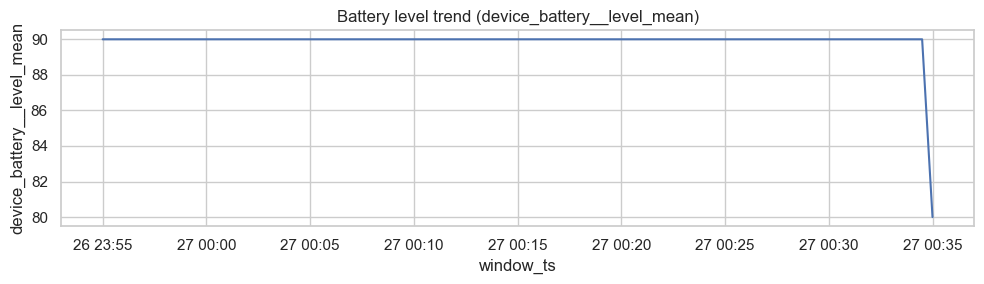

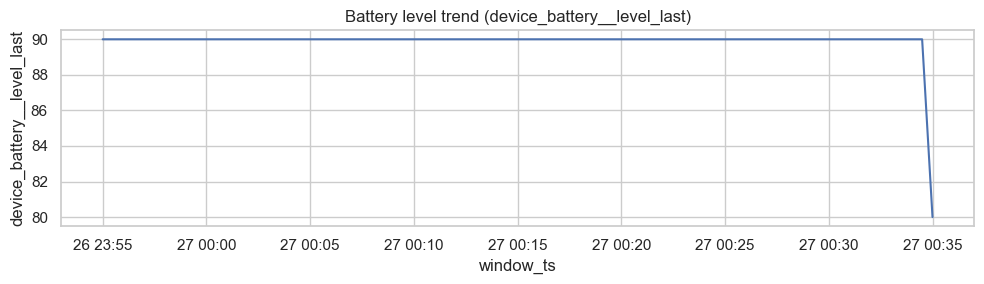

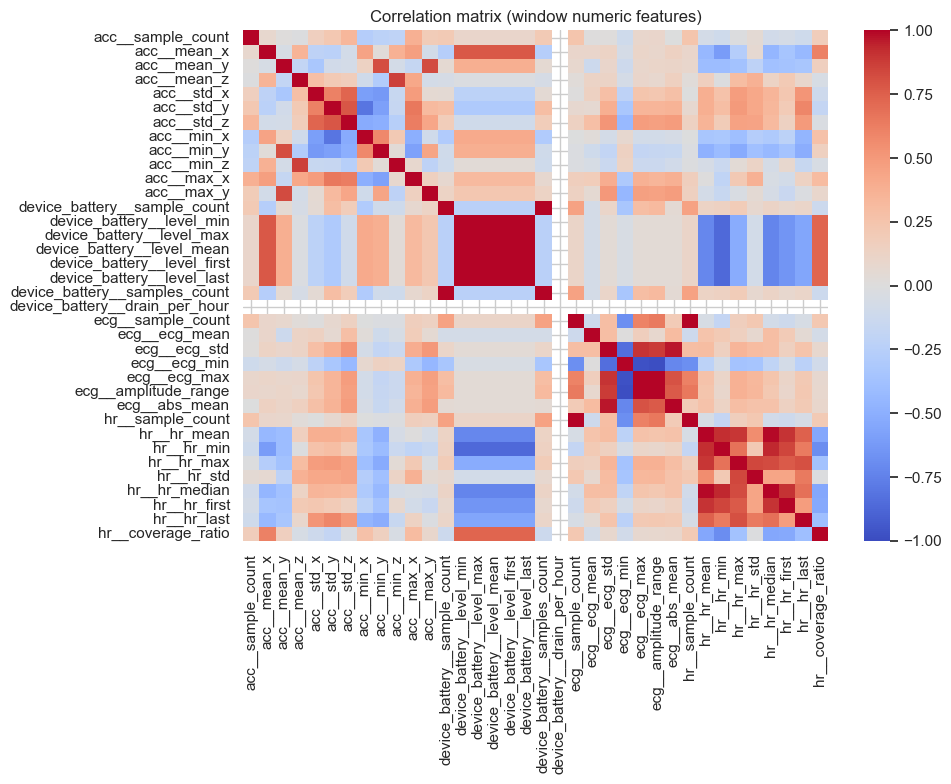

In [36]:
print('Exploratory only: hypothesis-generating, not causal and not production logic.')

feature_frames_named = {display_names.get(k, k): v for k, v in window_features.items() if v is not None and not v.empty}
joined = merge_feature_streams_by_time(feature_frames_named, max_rows_per_stream=3000)

if joined.empty:
    print('No joinable window features found.')
else:
    print('Joined rows:', len(joined.index))
    display(joined.head(10))

    def _scatter_if(cols, title):
        xcol, ycol = cols
        if xcol in joined.columns and ycol in joined.columns:
            s = joined[[xcol, ycol]].dropna()
            if not s.empty:
                plt.figure(figsize=(6, 4))
                sns.scatterplot(data=downsample_df(s, max_points=4000), x=xcol, y=ycol, s=20, alpha=0.5)
                plt.title(title)
                plt.tight_layout()
                plt.show()

    _scatter_if(('hr__mean_hr', 'acc__activity_energy'), 'HR mean vs ACC activity energy')
    _scatter_if(('hr__mean_hr', 'acc__vector_magnitude_mean'), 'HR mean vs ACC vector magnitude mean')
    _scatter_if(('ecg__amplitude_range', 'acc__activity_energy'), 'ECG amplitude range vs ACC activity energy')

    for col in [f'{battery_stream_alias}__level_mean', f'{battery_stream_alias}__level_last']:
        if col in joined.columns:
            plt.figure(figsize=(10, 3))
            sns.lineplot(data=joined[['window_ts', col]].dropna(), x='window_ts', y=col)
            plt.title(f'Battery level trend ({col})')
            plt.tight_layout()
            plt.show()

    numeric = joined.select_dtypes(include=['number'])
    if numeric.shape[1] >= 2:
        corr = numeric.corr(numeric_only=True)
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
        plt.title('Correlation matrix (window numeric features)')
        plt.tight_layout()
        plt.show()


## 14. Session Summary View


In [37]:
if summary:
    print(json.dumps(summary, indent=2, ensure_ascii=False))

    compact = {
        'session_id': summary.get('session_id'),
        'started_at_utc': summary.get('started_at_utc'),
        'ended_at_utc': summary.get('ended_at_utc'),
        'duration_seconds': summary.get('duration_seconds'),
        'crosses_midnight': summary.get('crosses_midnight'),
        'streams_present': ', '.join(summary.get('streams_present', []) or []),
        'streams_missing': ', '.join(summary.get('streams_missing', []) or []),
        'status': summary.get('status'),
    }
    display(pd.DataFrame([compact]))

    per_stream = summary.get('stream_summaries') or summary.get('streams') or {}
    if isinstance(per_stream, dict) and per_stream:
        rows = []
        for stream_name, details in per_stream.items():
            rows.append({
                'stream': stream_name,
                'status': details.get('status') if isinstance(details, dict) else None,
                'issues': details.get('issues') if isinstance(details, dict) else None,
                'keys': list(details.keys()) if isinstance(details, dict) else None,
            })
        display(pd.DataFrame(rows))
else:
    print('No session_summary.json found')


{
  "schema_version": "1.0",
  "session_id": "4fd8bc53-8971-4567-8c7f-81a3137c94da",
  "started_at_utc": "2026-04-26T23:55:00Z",
  "ended_at_utc": "2026-04-27T00:40:00Z",
  "duration_seconds": 2700,
  "crosses_midnight": true,
  "streams_present": [
    "hr",
    "acc",
    "ecg",
    "device_battery"
  ],
  "streams_missing": [],
  "stream_summaries": {
    "hr": {
      "status": "success",
      "coverage": {
        "window_counts": {
          "30s": 72,
          "1m": 37,
          "5m": 9
        },
        "estimated_duration_seconds": 2160
      },
      "hr_statistics": {
        "min": 45.733333333333334,
        "max": 92.73333333333333,
        "mean": 53.740895061728395,
        "median": 51.46666666666667,
        "std": 7.787677303661865,
        "p05": 46.725,
        "p10": 47.46333333333333,
        "p90": 61.39333333333333,
        "p95": 71.52166666666668,
        "range": 47.0,
        "cv": 0.14491156678199546
      },
      "trend": {
        "first_window_mean

,session_id,started_at_utc,ended_at_utc,duration_seconds,crosses_midnight,streams_present,streams_missing,status
0,4fd8bc53-8971-4567-8c7f-81a3137c94da,2026-04-26T23:55:00Z,2026-04-27T00:40:00Z,2700,True,"hr, acc, ecg, device_battery",,success


,stream,status,issues,keys
0,hr,success,None,"[status, coverage, hr_statistics, trend, extremes, data_quality, warnings, artifacts]"
1,acc,success,None,"[status, coverage, movement_activity, vector_magnitude, data_quality, warnings, artifacts]"
2,ecg,success,None,"[status, coverage, ecg_uv, amplitude_range, data_quality, warnings, artifacts]"
3,device_battery,success,None,"[status, coverage, battery, data_quality, warnings, artifacts]"


## 15. Data Quality / ML Readiness Report


In [38]:
readiness_rows = []

def _add_row(stream, usable, issues, next_step):
    readiness_rows.append({
        'stream': stream,
        'usable_for_ml': usable,
        'main_issues': issues,
        'suggested_next_investigation': next_step,
    })

if hr_quality:
    hr_issues = []
    if hr_quality.get('missing_hr', 0) > 0:
        hr_issues.append('missing HR samples')
    if hr_quality.get('implausible_hr_values', 0) > 0:
        hr_issues.append('implausible HR values')
    if (hr_quality.get('gap_p95_seconds') or 0) > 5:
        hr_issues.append('large HR gaps')
    rr_ratio = hr_quality.get('rr_availability_ratio')
    if rr_ratio is not None and rr_ratio < 0.5:
        hr_issues.append('low RR availability')
    _add_row('hr', 'yes' if not hr_issues else 'caution', ', '.join(hr_issues) or 'no major issues', 'Inspect missing/implausible segments by timestamp.')

if acc_quality:
    acc_issues = []
    if acc_quality.get('missing_axis_values', 0) > 0:
        acc_issues.append('missing axis values')
    if acc_quality.get('duplicate_timestamps', 0) > 0:
        acc_issues.append('duplicate timestamps')
    if (acc_quality.get('gap_p95_seconds') or 0) > 0.1:
        acc_issues.append('sampling instability/gaps')
    if acc_quality.get('extreme_values_count', 0) > 0:
        acc_issues.append('extreme acceleration spikes')
    _add_row('acc', 'yes' if not acc_issues else 'caution', ', '.join(acc_issues) or 'no major issues', 'Inspect axis calibration and gap clusters.')

if ecg_quality:
    ecg_issues = []
    if ecg_quality.get('missing_values', 0) > 0:
        ecg_issues.append('missing ECG values')
    if ecg_quality.get('flatline_like_windows', 0) > 0:
        ecg_issues.append('flatline-like segments')
    if ecg_quality.get('extreme_spike_count', 0) > 0:
        ecg_issues.append('extreme amplitude spikes')
    if (ecg_quality.get('gap_p95_seconds') or 0) > 0.05:
        ecg_issues.append('sampling gaps')
    ecg_usable = 'yes' if not ecg_issues else ('no' if 'flatline-like segments' in ecg_issues else 'caution')
    _add_row('ecg', ecg_usable, ', '.join(ecg_issues) or 'no major issues', 'Inspect spike/flatline windows and source packet boundaries.')

if battery_quality:
    batt_issues = []
    if battery_quality.get('drain_per_hour') is None:
        batt_issues.append('too sparse for drain rate')
    _add_row(battery_stream_alias, 'caution', ', '.join(batt_issues) or 'short session inference limits', 'Collect longer sessions for degradation trends.')

readiness_df = pd.DataFrame(readiness_rows)
display(readiness_df if not readiness_df.empty else pd.DataFrame(columns=['stream', 'usable_for_ml', 'main_issues', 'suggested_next_investigation']))


,stream,usable_for_ml,main_issues,suggested_next_investigation
0,hr,yes,no major issues,Inspect missing/implausible segments by timestamp.
1,acc,caution,"duplicate timestamps, sampling instability/gaps",Inspect axis calibration and gap clusters.
2,ecg,no,"flatline-like segments, extreme amplitude spikes, sampling gaps",Inspect spike/flatline windows and source packet boundaries.
3,device_battery,caution,short session inference limits,Collect longer sessions for degradation trends.


## 16. Optional Local EDA Report Save


In [39]:
if save_report:
    report_dir = NOTEBOOK_ROOT / 'data_cache' / 'eda_reports'
    report_dir.mkdir(parents=True, exist_ok=True)

    payload = {
        'session_id': selected_session_id,
        'user_id': user_id,
        'inventory': inventory_df.to_dict(orient='records') if 'inventory_df' in globals() else [],
        'coverage': coverage_df.to_dict(orient='records') if 'coverage_df' in globals() else [],
        'quality': {
            'hr': hr_quality if 'hr_quality' in globals() else {},
            'acc': acc_quality if 'acc_quality' in globals() else {},
            'ecg': ecg_quality if 'ecg_quality' in globals() else {},
            battery_stream_alias: battery_quality if 'battery_quality' in globals() else {},
        },
        'ml_readiness': readiness_df.to_dict(orient='records') if 'readiness_df' in globals() else [],
        'summary': summary,
    }

    report_path = report_dir / f'{selected_session_id}_h10_multistream_eda.json'
    report_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')
    print('Saved local report:', report_path)
else:
    print('Local report save skipped (save_report=False).')


Local report save skipped (save_report=False).
